<div style="display:flex; align-items:flex-start; justify-content:space-between; gap:24px; border-bottom:3px solid #8f001a; padding-bottom:16px;">
  <div>
    <h1 style="margin-bottom:0.35em;">Exercise 1: Explore, Plan, Code for Low-Flow Analysis</h1>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Faculty of Engineering, University of Ottawa</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Provided By:</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;">Professor Hossein Bonakdari</p>
    <p style="font-size:1.05em; margin:0.2em 0;">PhD Candidate Mohammad Hashtari</p>
  </div>
  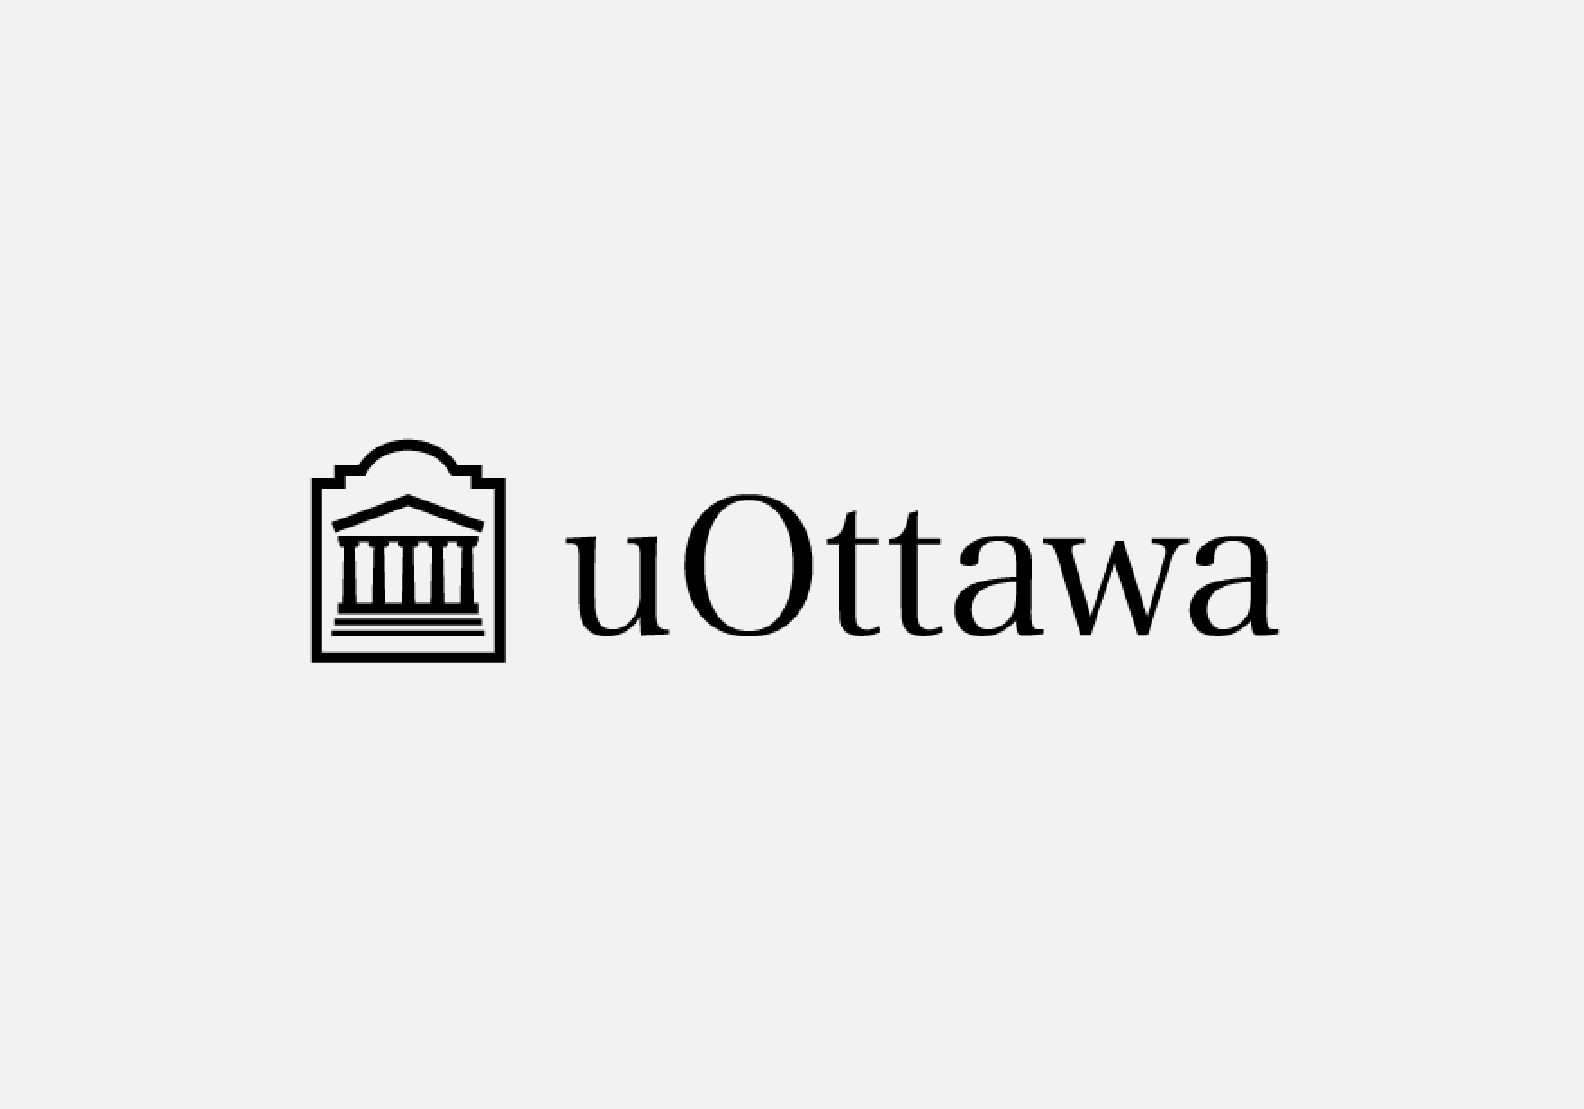
</div>

This notebook teaches a careful Python workflow for low-flow analysis. The focus is both the hydrological calculation and the coding habit: understand the existing code and data before writing new code.

In [ ]:
# Browser package setup for JupyterLite. Safe to run in local Jupyter too.
import sys

if sys.platform == "emscripten":
    import piplite
    await piplite.install(["numpy", "pandas", "matplotlib", "scipy"])


## 1. Source Basis

The hydrological calculation in this notebook is based on primary flow-duration and exceedance-flow references:

- Searcy, J. K. (1959). *Flow-duration curves*. U.S. Geological Survey Water-Supply Paper 1542-A. https://doi.org/10.3133/wsp1542A
- Vogel, R. M., and Fennessey, N. M. (1994). Flow-duration curves I: New interpretation and confidence intervals. *Journal of Water Resources Planning and Management*, 120(4), 485-504. https://doi.org/10.1061/(ASCE)0733-9496(1994)120:4(485)
- Weibull, W. (1939). *A statistical theory of the strength of materials*. Royal Swedish Institute for Engineering Research, Proceedings No. 151.

Searcy defines the flow-duration curve as a cumulative-frequency curve showing the percentage of time that specified discharges are equaled or exceeded. Vogel and Fennessey formalize the flow-duration curve as the complement of the streamflow cumulative distribution function. The plotted exceedance positions below use the common Weibull plotting position.

## 2. Learning Goal

A coding assistant should not immediately edit unfamiliar hydrology code. The safer sequence is:

1. Explore the existing data and functions.
2. Plan the exact change.
3. Implement the smallest correct function.
4. Verify the result with tests and a hydrologically meaningful check.

Hydrology target: compute Q90 and Q95, where Q90 is the discharge exceeded 90% of the time and Q95 is the discharge exceeded 95% of the time. Under this convention, Q90 is the 10th percentile and Q95 is the 5th percentile of daily discharge.

## 3. Libraries

The notebook uses only standard scientific Python tools: `numpy`, `pandas`, and `matplotlib`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

RANDOM_STATE = 42

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 4. Sample Daily Discharge Series

The data below are fictional daily flows for a two-year gauge record. The structure is intentionally simple: one date index and one discharge column in cubic metres per second. The pattern includes spring high flows, autumn events, and late-summer low flows.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)

dates = pd.date_range("2022-01-01", "2023-12-31", freq="D")
day_of_year = dates.dayofyear.to_numpy()

baseflow = 13.0 + 4.0 * np.cos(2 * np.pi * (day_of_year - 20) / 365.25)
spring_freshet = 95.0 * np.exp(-0.5 * ((day_of_year - 70) / 10.0) ** 2)
autumn_event = 55.0 * np.exp(-0.5 * ((day_of_year - 310) / 7.0) ** 2)
dry_year_shift = np.where(dates.year == 2023, -2.2, 0.0)
noise = rng.normal(0.0, 0.25, len(dates))

discharge = np.maximum(0.1, baseflow + spring_freshet + autumn_event + dry_year_shift + noise)

flow_df = pd.DataFrame({"discharge_m3s": discharge}, index=dates)
flow_df.index.name = "date"

flow_df.head()

In [ ]:
fig, ax = plt.subplots()
ax.plot(flow_df.index, flow_df["discharge_m3s"], color="#1f6f8b", linewidth=1.4)
ax.set_title("Fictional Daily Streamflow Record")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (m3/s)")
plt.show()

## 5. Existing Code to Explore

Before asking an assistant to add Q90 and Q95, first inspect what already exists. In a real project, this means reading the source file, checking column names, and reading the tests. In this notebook, the existing functions are shown directly.

In [ ]:
def load_flow_data(df: pd.DataFrame) -> pd.DataFrame:
    """Return a sorted daily discharge DataFrame."""
    loaded = df.copy()
    loaded.index = pd.to_datetime(loaded.index)
    return loaded.sort_index()


def compute_basic_stats(df: pd.DataFrame) -> dict:
    """Compute mean, standard deviation, minimum, and maximum discharge."""
    q = df["discharge_m3s"]
    return {
        "mean": float(q.mean()),
        "std": float(q.std()),
        "min": float(q.min()),
        "max": float(q.max()),
    }


def find_peak_flows(df: pd.DataFrame, n: int = 5) -> pd.DataFrame:
    """Return the n highest daily discharge values."""
    return df.nlargest(n, "discharge_m3s")

In [ ]:
flow_data = load_flow_data(flow_df)
basic_stats = compute_basic_stats(flow_data)
peak_flows = find_peak_flows(flow_data, n=5)

basic_stats, peak_flows

## 6. Concept Graph

The important habit is the order of operations. The assistant should not jump from request directly to code.

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.set_axis_off()

steps = [
    ('Explore', 'Read data, functions, tests'),
    ('Plan', 'Define exact change'),
    ('Code', 'Implement one function'),
    ('Verify', 'Run tests and inspect flow logic'),
]

x = 0.12
width = 0.76
height = 0.105
if len(steps) == 1:
    y_positions = [0.50]
else:
    y_positions = [0.78 - i * (0.66 / (len(steps) - 1)) for i in range(len(steps))]

for i, ((step_title, subtitle), y) in enumerate(zip(steps, y_positions)):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="#264653",
        facecolor="#edf6f9",
        transform=ax.transAxes,
    )
    ax.add_patch(box)
    ax.text(x + 0.035, y + height * 0.64, step_title, ha="left", va="center", fontsize=11, weight="bold", transform=ax.transAxes)
    ax.text(x + 0.035, y + height * 0.30, subtitle, ha="left", va="center", fontsize=9, transform=ax.transAxes)
    if i < len(steps) - 1:
        next_y = y_positions[i + 1]
        ax.annotate(
            "", xy=(0.50, next_y + height + 0.015), xytext=(0.50, y - 0.015),
            arrowprops={"arrowstyle": "->", "lw": 1.4, "color": "#264653"},
            xycoords=ax.transAxes,
        )

ax.set_title('Explore Before Editing', pad=12)
plt.show()

## 7. Before Prompt

A weak prompt skips context and makes the assistant guess:

```text
Add Q90 and Q95 to my flow script.
```

This may work in a tiny example, but it does not force the assistant to check column names, existing style, edge cases, or tests.

## 8. After Prompt

A stronger prompt separates exploration from implementation:

```text
First inspect the existing notebook cells that define load_flow_data, compute_basic_stats, and find_peak_flows.
Confirm the discharge column name and units.
Then propose a short plan for compute_exceedance_flows(df), where Q90 is the flow exceeded 90% of the time and Q95 is the flow exceeded 95% of the time.
After the plan, implement the function and add tests for percentile values and hydrological ordering.
```

This prompt tells the assistant what to inspect, what convention to use, and how to verify the answer.

## 9. Implementation

For a flow-duration convention, Q90 is computed as the 10th percentile of daily discharge and Q95 as the 5th percentile. This means Q95 should be less than or equal to Q90.

In [ ]:
def compute_exceedance_flows(df: pd.DataFrame) -> dict:
    """Compute Q90 and Q95 discharge thresholds in m3/s."""
    q = df["discharge_m3s"].dropna()
    return {
        "Q90": float(np.percentile(q, 10)),
        "Q95": float(np.percentile(q, 5)),
    }


exceedance_flows = compute_exceedance_flows(flow_data)
exceedance_flows

## 10. Verification Tests

The tests check both numerical correctness and hydrological ordering. Numerical tests protect the implementation; ordering protects the low-flow interpretation.

In [ ]:
expected_q90 = np.percentile(flow_data["discharge_m3s"], 10)
expected_q95 = np.percentile(flow_data["discharge_m3s"], 5)

assert np.isclose(exceedance_flows["Q90"], expected_q90)
assert np.isclose(exceedance_flows["Q95"], expected_q95)
assert exceedance_flows["Q95"] <= exceedance_flows["Q90"]
assert exceedance_flows["Q90"] <= basic_stats["mean"]

print("All checks passed.")

## 11. Flow-Duration View

A flow-duration curve makes the Q90 and Q95 convention visible. The x-axis is exceedance probability. Larger probabilities correspond to lower, more persistent flows.

In [ ]:
q_sorted = np.sort(flow_data["discharge_m3s"].to_numpy())[::-1]
exceedance_probability = 100 * (np.arange(1, len(q_sorted) + 1) / (len(q_sorted) + 1))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(exceedance_probability, q_sorted, color="#0b7285", linewidth=2)

for label, probability in [("Q90", 90), ("Q95", 95)]:
    value = exceedance_flows[label]
    ax.axvline(probability, color="#d9480f", linestyle="--", linewidth=1)
    ax.axhline(value, color="#d9480f", linestyle=":", linewidth=1)
    ax.text(probability - 8, value + 1.2, f"{label} = {value:.2f} m3/s", color="#9a3412")

ax.set_title("Flow-Duration Curve with Low-Flow Thresholds")
ax.set_xlabel("Exceedance probability (%)")
ax.set_ylabel("Discharge (m3/s)")
ax.set_xlim(0, 100)
plt.show()

## 12. Hydrological Interpretation

Q90 and Q95 summarize the lower tail of the discharge distribution. In this fictional record, Q95 is lower than Q90 because it represents a more persistent low-flow condition. These thresholds are useful for screening water availability, drought sensitivity, and environmental-flow constraints, but they should not be interpreted as universal basin behaviour from a two-year synthetic record.

## 13. Summary

- Explore first: identify data structure, units, and existing functions.
- Plan before editing: define the convention and exact code change.
- Code narrowly: add only `compute_exceedance_flows(df)`.
- Verify: compare against expected percentiles and check Q95 <= Q90.

The clean AI-coding habit is transferable: slow the assistant down before the code changes, especially when hydrological meaning depends on conventions, units, or time-step assumptions.